In [33]:
print("="*70)
print("📊 CODVEDA - LEVEL 1 TASK 2: EXPLORATORY DATA ANALYSIS")
print("="*70)

📊 CODVEDA - LEVEL 1 TASK 2: EXPLORATORY DATA ANALYSIS


In [35]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

data_path = Path("../data/raw/stock_prices.csv")
df = pd.read_csv(data_path)

print("DATA LOADED SUCCESSFULLY")
print("Shape:", df.shape)
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())

DATA LOADED SUCCESSFULLY
Shape: (497472, 7)
Shape: (497472, 7)
Columns: ['symbol', 'date', 'open', 'high', 'low', 'close', 'volume']


In [36]:
print("="*50)
print("DATASET OVERVIEW")
print("="*50)

print("Number of Companies:", df['symbol'].nunique())
print("Date Range:", df['date'].min(), "to", df['date'].max())

DATASET OVERVIEW
Number of Companies: 505
Date Range: 2014-01-02 to 2017-12-29


In [37]:
print("="*50)
print("DATA QUALITY CHECK")
print("="*50)

print("Missing Values:\n", df.isnull().sum())
print("\nDuplicate Rows:", df.duplicated().sum())

DATA QUALITY CHECK
Missing Values:
 symbol     0
date       0
open      11
high       8
low        8
close      0
volume     0
dtype: int64

Duplicate Rows: 0


In [38]:
df['date'] = pd.to_datetime(df['date'])

print("Date column converted successfully")

Date column converted successfully


In [39]:
print("="*50)
print("SUMMARY STATISTICS")
print("="*50)

print(df[['open','high','low','close','volume']].describe())

SUMMARY STATISTICS
                open           high            low          close  \
count  497461.000000  497464.000000  497464.000000  497472.000000   
mean       86.352275      87.132562      85.552467      86.369082   
std       101.471228     102.312062     100.570957     101.472407   
min         1.620000       1.690000       1.500000       1.590000   
25%        41.690000      42.090000      41.280000      41.703750   
50%        64.970000      65.560000      64.353700      64.980000   
75%        98.410000      99.230000      97.580000      98.420000   
max      2044.000000    2067.990000    2035.110000    2049.000000   

             volume  
count  4.974720e+05  
mean   4.253611e+06  
std    8.232139e+06  
min    0.000000e+00  
25%    1.080166e+06  
50%    2.084896e+06  
75%    4.271928e+06  
max    6.182376e+08  


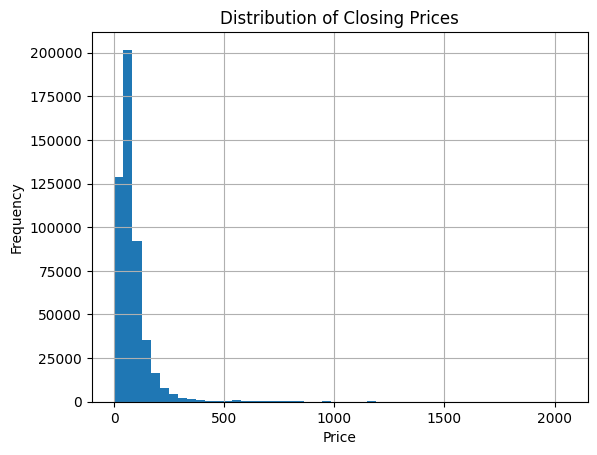

<Figure size 640x480 with 0 Axes>

In [42]:
import matplotlib.pyplot as plt

df['close'].hist(bins=50)

plt.title("Distribution of Closing Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")

plt.show()
plt.savefig("../reports/figures/aapl_closing_price_distribution.png")

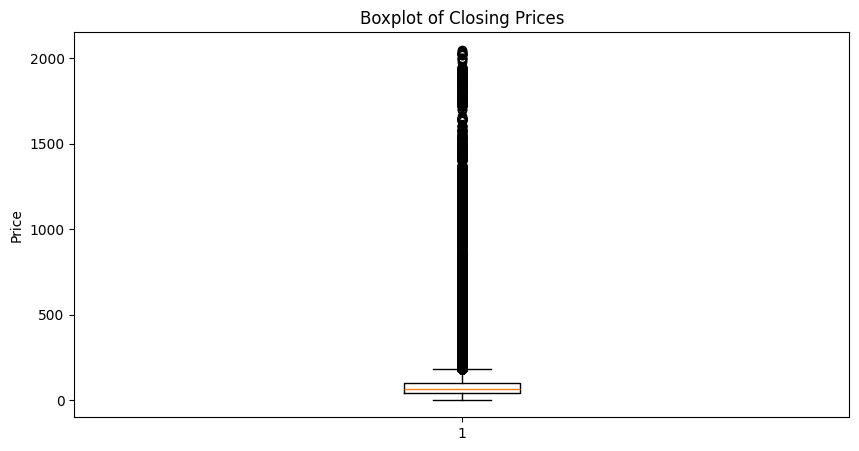

<Figure size 640x480 with 0 Axes>

In [45]:
plt.figure(figsize=(10,5))
plt.boxplot(df['close'])

plt.title("Boxplot of Closing Prices")
plt.ylabel("Price")

plt.show()
plt.savefig("../reports/figures/aapl_closing_price_boxplot.png")

Correlation Matrix:
            open      high       low     close    volume
open    1.000000  0.999941  0.999928  0.999876 -0.148724
high    0.999941  1.000000  0.999905  0.999938 -0.148344
low     0.999928  0.999905  1.000000  0.999941 -0.149284
close   0.999876  0.999938  0.999941  1.000000 -0.148839
volume -0.148724 -0.148344 -0.149284 -0.148839  1.000000


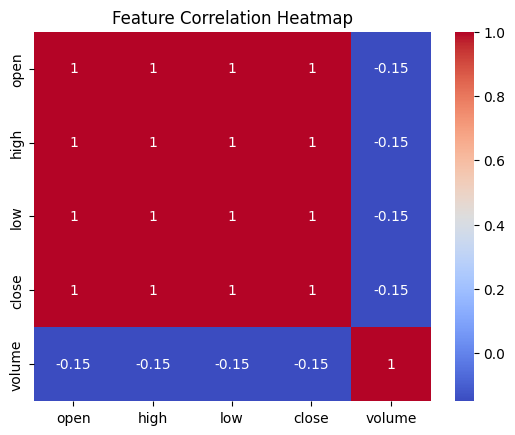

<Figure size 640x480 with 0 Axes>

In [47]:
import seaborn as sns

corr = df[['open','high','low','close','volume']].corr()

print("Correlation Matrix:")
print(corr)

sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()
plt.savefig("../reports/figures/aapl_feature_correlation_heatmap.png")

In [48]:
top_volume = df.groupby('symbol')['volume'].sum().sort_values(ascending=False).head(10)

print("="*50)
print("TOP 10 MOST TRADED STOCKS")
print("="*50)

print(top_volume)

TOP 10 MOST TRADED STOCKS
symbol
BAC     89988444028
AAPL    45485758169
GE      41734050117
AMD     33522535638
F       33144701045
MSFT    30927601441
FB      29432418373
MU      28158553783
CHK     28080599383
INTC    27351266285
Name: volume, dtype: int64


In [49]:
df['returns'] = df.groupby('symbol')['close'].pct_change()

print("Returns calculated successfully")

Returns calculated successfully


In [50]:
volatility = df.groupby('symbol')['returns'].std().sort_values(ascending=False).head(10)

print("="*50)
print("TOP 10 MOST VOLATILE STOCKS")
print("="*50)

print(volatility)

TOP 10 MOST VOLATILE STOCKS
symbol
CHK     0.045515
AMD     0.039102
LNT     0.037006
FCX     0.036989
BHGE    0.036615
WMB     0.032347
MRO     0.032164
EVHC    0.029553
RRC     0.029073
INCY    0.028560
Name: returns, dtype: float64


In [51]:
aapl = df[df['symbol'] == 'AAPL'].copy()

print("AAPL Shape:", aapl.shape)

AAPL Shape: (1007, 8)


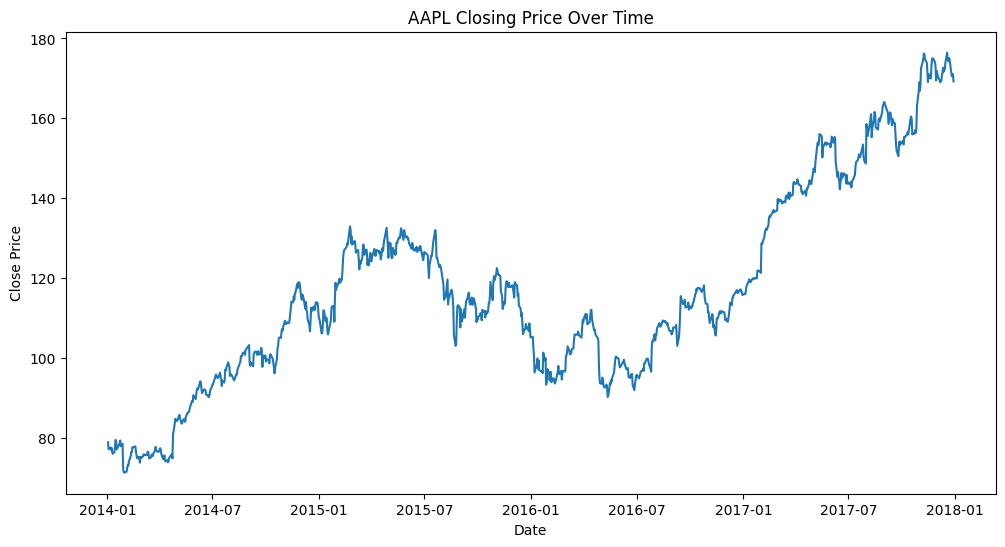

<Figure size 640x480 with 0 Axes>

In [52]:
plt.figure(figsize=(12,6))
plt.plot(aapl['date'], aapl['close'])

plt.title("AAPL Closing Price Over Time")
plt.xlabel("Date")
plt.ylabel("Close Price")

plt.show()
plt.savefig("../reports/figures/aapl_closing_price_over_time.png")

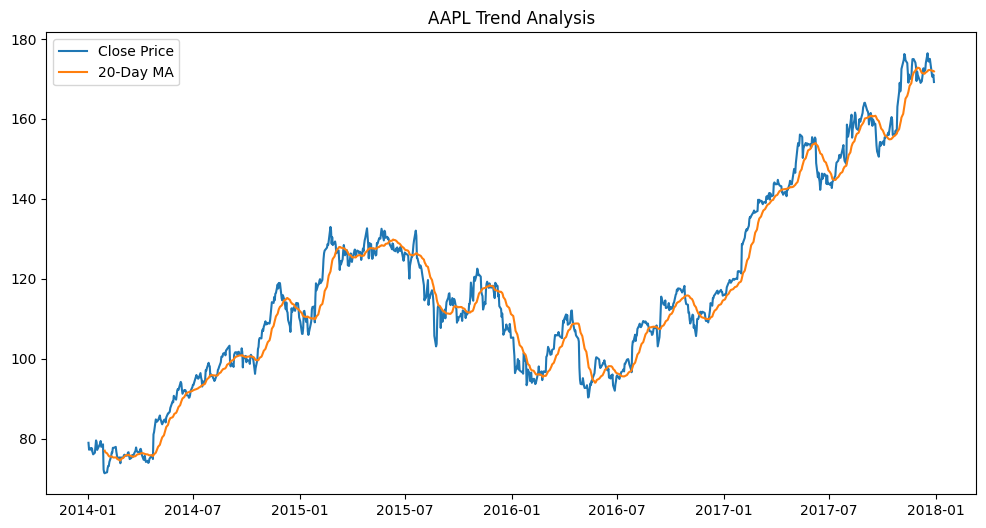

<Figure size 640x480 with 0 Axes>

In [54]:
aapl['MA20'] = aapl['close'].rolling(20).mean()

plt.figure(figsize=(12,6))
plt.plot(aapl['date'], aapl['close'], label='Close Price')
plt.plot(aapl['date'], aapl['MA20'], label='20-Day MA')

plt.title("AAPL Trend Analysis")
plt.legend()

plt.show()
plt.savefig("../reports/figures/aapl_trend_analysis.png")

In [55]:
print("="*70)
print("📌 KEY INSIGHTS FROM EDA")
print("="*70)

print("""
1. Dataset contains 505 companies with ~497K records.
2. No missing or duplicate values found.
3. Stock prices show strong correlation between open, high, low, close.
4. Volume varies significantly across companies.
5. Some stocks show high volatility (higher risk).
6. AAPL shows stable long-term upward trend.
7. Moving average confirms smooth market trend.
""")

📌 KEY INSIGHTS FROM EDA

1. Dataset contains 505 companies with ~497K records.
2. No missing or duplicate values found.
3. Stock prices show strong correlation between open, high, low, close.
4. Volume varies significantly across companies.
5. Some stocks show high volatility (higher risk).
6. AAPL shows stable long-term upward trend.
7. Moving average confirms smooth market trend.



In [56]:
print("="*70)
print("🎯 LEVEL 1 - TASK 2 COMPLETED SUCCESSFULLY")
print("="*70)

🎯 LEVEL 1 - TASK 2 COMPLETED SUCCESSFULLY
